# PMX QSAR Regression (Corrected pIC50, RDKit + Morgan)
**Walters-style notebook (annotated, reproducible, external scaffold validation, new-analogue scoring)**

- Target: **Corrected pIC50** (column `D10` in your  CSV)
- Features: **RDKit 2D descriptors + Crippen (RDKit) + Morgan fingerprints**
- Validation: **External scaffold holdout** (Murcko) + **GroupKFold CV on train**
- Reporting: metrics table, parity, residuals, learning curve, y-randomisation, AD (SIM_5), permutation importance

> This notebook is inspired by the structure/flow Pat Walters uses in his regression tutorial notebooks (clean data → descriptors → baseline → model → diagnostics → predict new molecules).

## 0. Environment setup
### Recommended conda environment (VS Code / Jupyter)
Run **one** of the following in your terminal (not in the notebook):

```bash
conda create -n pmx_qsar -c conda-forge python=3.10 rdkit scikit-learn pandas numpy scipy matplotlib joblib tqdm shap
conda activate pmx_qsar
```

**Notes**
- **Crippen descriptors are included in RDKit** (`rdkit.Chem.Crippen`) → no extra install.
- Optional (only if you later want extra descriptor families):
```bash
conda install -c conda-forge mordredcommunity
```

In [1]:
# 1) Imports & version reporting
import sys, platform, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Descriptors
from rdkit.Chem import Crippen
from rdkit.Chem import PandasTools

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve

import joblib

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP not available:", e)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    import rdkit
    print("RDKit:", rdkit.__version__)
except Exception:
    pass
import sklearn
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

Failed to patch pandas - PandasTools will have limited functionality


Python: 3.11.14
Platform: Windows-10-10.0.26200-SP0
RDKit: 2025.09.4
sklearn: 1.8.0
numpy: 2.3.5
pandas: 3.0.0


## 1. Configuration
Update `CSV_PATH` if needed. This notebook assumes:
- SMILES column exists (we autodetect common names)
- Target column is `Corrected pIC50(D10)` = corrected pIC50
- Optional ID column exists (we autodetect common names)


In [2]:
# 2) Paths and key columns
CSV_PATH = "  # adjust if needed

TARGET_COL = "pIC50"  


CAND_SMILES = ["SMILES", "smiles", "Structure", "structure", "CanonicalSMILES", "canonical_smiles"]
CAND_ID = ["ID", "Compound_ID", "Compound", "Name", "Molecule", "MolID"]

RANDOM_SEED = 42
TEST_SIZE = 0.20

MORGAN_RADIUS = 2
MORGAN_BITS = 2048

np.random.seed(RANDOM_SEED)

## 2. Load data + quick audit
We do a minimal but strict cleaning:
- Drop rows with missing/invalid SMILES
- Drop rows with missing target (`D10`)
- Parse RDKit mols; drop failures
- Show target distribution and duplicates


In [3]:
# 3) Load data
df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)
df.head()

Raw shape: (324, 101)


,ID,Structure,IC50(D10),IC50(D10)_StdDev,Corr. IC50(D10) by 1% Alb,Corr. IC50(D10) by 1% Alb_StdDev,Corrected pIC50(D10),Corrected pIC50(D10)_StdDev,AZ_LogD74,AZ_LogD74_StdDev,...,Corrected HLM by fu,Corrected HLM by fu_StdDev,iLLE,iLLE_StdDev,LLE,LLE_StdDev,"Pred. Vdss,u","Pred. Vdss,u_StdDev",Cal. pKa,Cal. pKa_StdDev
0,AC-2-022,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccc(cc2)Br)NC...,2.01,0.63,0.6637,0.2080,9.178,0.136100,2.4,0.0,...,596.3,259.40,5.7,0.4559,6.778,0.136100,209.30,0.0,8.44,0.4748
1,AC-2-030,c1ccc(cc1)C[C@@H]([C@@H](CNC2(CC2)c3ccc(cc3)F)...,304.2,3.01,91.1,0.9014,7.04,0.004297,2.5,0.0,...,537.5,197.80,4.023,0.4351,4.54,0.004297,42.56,0.0,7.761,0.6247
2,AC-2-035,CC(C)(c1ccccc1)NC[C@H]([C@H](Cc2ccccc2)NC(=O)c...,13.31,5.01,5.872,2.2100,8.231,0.163500,1.6,0.0,...,336,129.00,5.113,0.4648,6.631,0.163500,27.87,0.0,8.905,0.4487
3,AC-2-038,C[C@H](c1ccc(cc1)C(F)(F)F)NC[C@H]([C@H](Cc2ccc...,33.11,0.74,9.686,0.2165,8.014,0.009706,2.8,0.0,...,1149,514.50,4.43,0.4352,5.214,0.009706,117.30,0.0,8.106,0.5208
4,AC-2-040,C[C@H](c1ccc(cc1)F)NC[C@H]([C@H](Cc2ccccc2)NC(...,12.94,0.37,5.622,0.1607,8.25,0.012420,1.7,0.0,...,134.4,46.82,5.349,0.4353,6.55,0.012420,40.06,0.0,8.573,0.4643


In [4]:
# 4) Detect columns
smiles_col = next((c for c in CAND_SMILES if c in df.columns), None)
id_col = next((c for c in CAND_ID if c in df.columns), None)

if smiles_col is None:
    raise ValueError(f"Could not find a SMILES column. Looked for: {CAND_SMILES}. Columns: {list(df.columns)[:50]}")
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column {TARGET_COL} not in CSV. Available columns include: {list(df.columns)[:50]}")

print("SMILES column:", smiles_col)
print("ID column:", id_col)

SMILES column: Structure
ID column: ID


In [5]:
# 5) Clean target + SMILES
df = df.copy()
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df[smiles_col] = df[smiles_col].astype(str)

df = df[df[TARGET_COL].notna()].copy()
df = df[df[smiles_col].notna() & (df[smiles_col].str.len() > 0)].copy()
print("After dropping missing target/SMILES:", df.shape)

# duplicate checks
if id_col is not None:
    print("Duplicate IDs:", int(df[id_col].duplicated().sum()))
print("Duplicate SMILES:", int(df[smiles_col].duplicated().sum()))

After dropping missing target/SMILES: (225, 101)
Duplicate IDs: 0
Duplicate SMILES: 0


In [6]:
# 6) Parse RDKit mols (no tqdm.pandas; avoids pandas/tqdm compatibility issues)
df["Mol"] = df[smiles_col].apply(lambda s: Chem.MolFromSmiles(str(s)))

bad = df["Mol"].isna().sum()
print("Bad mols:", int(bad))

df = df[df["Mol"].notna()].copy()
df.reset_index(drop=True, inplace=True)
print("After dropping bad mols:", df.shape)


Bad mols: 0
After dropping bad mols: (225, 102)


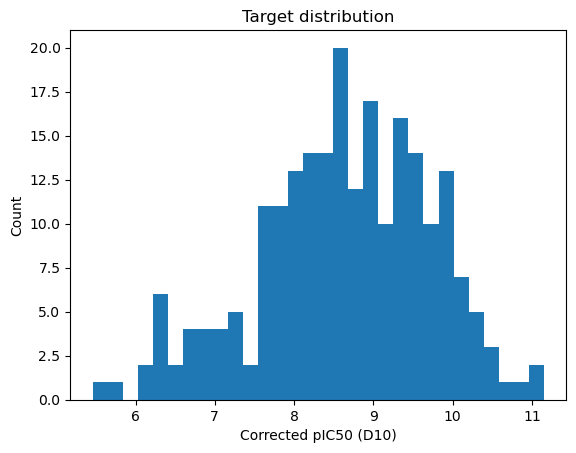

Target stats: count    225.000000
mean       8.631138
std        1.087107
min        5.461000
25%        7.966000
50%        8.667000
75%        9.423000
max       11.150000
dtype: float64


In [7]:
# 7) Target distribution
y_all = df[TARGET_COL].astype(float).values

plt.figure()
plt.hist(y_all, bins=30)
plt.xlabel("Corrected pIC50 (D10)")
plt.ylabel("Count")
plt.title("Target distribution")
plt.show()

print("Target stats:", pd.Series(y_all).describe())

## 3. Feature generation (RDKit descriptors + Crippen + Morgan bits)
### Descriptor policy
- Use **only structure-derived features** (per your request)
- RDKit 2D descriptors (a curated subset + Crippen logP/MR)
- Morgan fingerprints as 0/1 bit vectors

We keep descriptors in a dataframe (`X_desc`) and fingerprints in a dataframe (`X_fp`), then concatenate.


In [8]:
# 8) RDKit descriptor set (curated, stable)

DESC_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumHDonors": Descriptors.NumHDonors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "RingCount": Descriptors.RingCount,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "TPSA": Descriptors.TPSA,
    "FractionCSP3": Descriptors.FractionCSP3,
    "MolLogP_Crippen": Crippen.MolLogP,   
    "MolMR_Crippen": Crippen.MolMR,
    "NHOHCount": Descriptors.NHOHCount,
    "NOCount": Descriptors.NOCount,
    "LabuteASA": Descriptors.LabuteASA,
}

def compute_desc(mol):
    return {k: float(fn(mol)) for k, fn in DESC_FUNCS.items()}

def compute_morgan_bits(mol, radius=2, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# compute
desc_rows = []
fp_rows = []
for m in tqdm(df["Mol"].tolist(), desc="Computing descriptors/fps"):
    desc_rows.append(compute_desc(m))
    fp_rows.append(compute_morgan_bits(m, radius=MORGAN_RADIUS, n_bits=MORGAN_BITS))

X_desc = pd.DataFrame(desc_rows)
X_fp = pd.DataFrame(fp_rows, columns=[f"morgan_{i}" for i in range(MORGAN_BITS)])

X = pd.concat([X_desc, X_fp], axis=1)
y = df[TARGET_COL].astype(float).values

print("X shape:", X.shape, "y shape:", y.shape)
X.head()

Computing descriptors/fps:   0%|          | 0/225 [00:00<?, ?it/s]

X shape: (225, 2062) y shape: (225,)


[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerator
[13:39:33] DEPRECATION WARNING: please use MorganGenerat

,MolWt,HeavyAtomCount,NumHAcceptors,NumHDonors,NumRotatableBonds,RingCount,NumAromaticRings,TPSA,FractionCSP3,MolLogP_Crippen,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,593.566,39.0,5.0,3.0,10.0,4.0,3.0,84.91,0.354839,3.8895,...,0,0,0,0,0,0,0,0,0,1
1,531.628,39.0,5.0,3.0,10.0,5.0,3.0,90.90,0.354839,3.2790,...,0,0,0,0,0,0,0,0,0,0
2,515.654,38.0,5.0,3.0,10.0,4.0,3.0,90.90,0.354839,3.3859,...,0,0,0,0,0,0,0,0,0,0
3,569.624,41.0,5.0,3.0,10.0,4.0,3.0,90.90,0.354839,4.2306,...,0,0,0,0,0,0,0,0,0,1
4,519.617,38.0,5.0,3.0,10.0,4.0,3.0,90.90,0.333333,3.3509,...,0,0,0,0,0,0,0,0,0,1


## 4. Scaffold groups (Murcko) + external test split
We compute Murcko scaffolds and use them as **groups**.
External test is a **GroupShuffleSplit** on scaffolds, giving a realistic "new scaffold" holdout.


In [9]:
# 9) Murcko scaffold groups
def murcko_smiles(mol):
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf, isomericSmiles=False)
    except Exception:
        return "NA"

scaffolds = df["Mol"].apply(murcko_smiles).values
df["Scaffold"] = scaffolds

print("Unique scaffolds:", len(set(scaffolds)))
df["Scaffold"].value_counts().head(10)

Unique scaffolds: 104


Scaffold
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCNCC2)cc1         37
O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1ccc(C(=O)N2CCCCC2)cc1          24
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCCCC2)cc1         13
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCOCC2)cc1          8
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(CN2CCNCC2)cc1              6
O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1ccc(C(=O)N2CCNCC2)cc1           6
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(N2CCNCC2=O)cc1             5
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccccc1                         4
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CC3(CNC3)C2)cc1     4
O=C(NC(CCNC1CCCC1)Cc1ccccc1)c1ccc(C(=O)N2CCNCC2)cc1            4
Name: count, dtype: int64

In [10]:
# 10) External scaffold holdout split
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
idx = np.arange(len(df))
train_idx, test_idx = next(gss.split(idx, groups=scaffolds))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]
scaf_train, scaf_test = scaffolds[train_idx], scaffolds[test_idx]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train scaffolds:", len(set(scaf_train)), "Test scaffolds:", len(set(scaf_test)))

Train: (201, 2062) Test: (24, 2062)
Train scaffolds: 83 Test scaffolds: 21


## 5. Baselines (Walters-style sanity checks)
We compare:
1) **DummyRegressor** (predict mean)
2) **Ridge** on descriptors only (no fingerprints)
3) **RandomForest** on descriptors+fingerprints (main model)

We evaluate on the **external scaffold test**.


In [11]:
# 11) Metrics helpers
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def spearman_r(y_true, y_pred):
    return float(pd.Series(y_true).corr(pd.Series(y_pred), method="spearman"))

def regression_report(y_true, y_pred, label):
    return {
        "Split": label,
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Spearman": spearman_r(y_true, y_pred),
        "n": int(len(y_true))
    }

In [12]:
# 12) Dummy baseline
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

pred_dummy_train = dummy.predict(X_train)
pred_dummy_test = dummy.predict(X_test)

pd.DataFrame([
    regression_report(y_train, pred_dummy_train, "Train (Dummy)"),
    regression_report(y_test, pred_dummy_test, "External (Dummy)")
])

c:\Users\hllpacke\.conda\envs\PMX\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\hllpacke\.conda\envs\PMX\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,Split,RMSE,MAE,R2,Spearman,n
0,Train (Dummy),1.040474,0.832616,0.000000,NaN,201
1,External (Dummy),1.419032,1.109676,-0.304623,NaN,24


In [13]:
# 13) Ridge baseline (descriptors only)
Xdesc_train = X_desc.iloc[train_idx].copy()
Xdesc_test  = X_desc.iloc[test_idx].copy()

ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_SEED))
])

ridge.fit(Xdesc_train, y_train)
pred_ridge_train = ridge.predict(Xdesc_train)
pred_ridge_test  = ridge.predict(Xdesc_test)

pd.DataFrame([
    regression_report(y_train, pred_ridge_train, "Train (Ridge, desc)"),
    regression_report(y_test, pred_ridge_test, "External (Ridge, desc)")
])

,Split,RMSE,MAE,R2,Spearman,n
0,"Train (Ridge, desc)",0.832416,0.676242,0.359943,0.57221,201
1,"External (Ridge, desc)",0.879263,0.723877,0.499114,0.74000,24


## 6. Main model: RandomForest (tuned) + GroupKFold CV on train
We tune RF hyperparameters using **GroupKFold** on the training set (grouped by scaffold),
then evaluate once on the external scaffold holdout.


In [16]:
# 14) RF pipeline (Walters-style: simple + robust)
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("var", VarianceThreshold(0.0)),
    ("rf", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1))
])

param_dist = {
    "rf__n_estimators": [600, 900, 1200, 1600],
    "rf__max_depth": [None, 10, 14, 18, 26],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4, 8],
    "rf__max_features": ["sqrt", 0.2, 0.35, 0.5, 0.8],
    "rf__bootstrap": [True],
}

gkf = GroupKFold(n_splits=5)
cv_iter = list(gkf.split(X_train, y_train, groups=scaf_train))

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",  
    cv=cv_iter,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

# Backward compatibility for older sklearn without neg_root_mean_squared_error
try:
    search.fit(X_train, y_train)
except Exception as e:
    print("Falling back to neg_mean_squared_error due to:", e)
    search = RandomizedSearchCV(
        rf_pipe,
        param_distributions=param_dist,
        n_iter=40,
        scoring="neg_mean_squared_error",
        cv=cv_iter,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best params:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'rf__n_estimators': 900, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.5, 'rf__max_depth': 18, 'rf__bootstrap': True}


In [17]:
# 15) Predict train/test with tuned RF
pred_train = best_model.predict(X_train)
pred_test  = best_model.predict(X_test)

metrics_df = pd.DataFrame([
    regression_report(y_train, pred_train, "Train (RF tuned)"),
    regression_report(y_test, pred_test, "External (RF tuned, scaffold holdout)")
])
metrics_df

,Split,RMSE,MAE,R2,Spearman,n
0,Train (RF tuned),0.253617,0.187916,0.940585,0.982460,201
1,"External (RF tuned, scaffold holdout)",0.799055,0.680884,0.586330,0.826957,24


## 7. Model diagnostics (plots)
These are the core regression plots you should always have in a QSAR report:
- Parity plot
- Residuals vs predicted
- Residual distribution
- Absolute error vs experimental


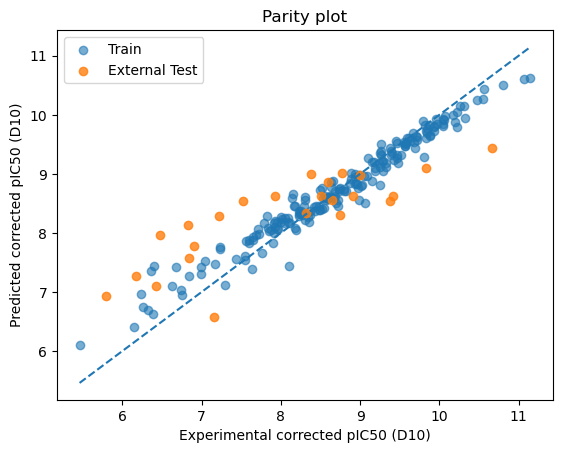

In [18]:
# 16) Parity plot
plt.figure()
plt.scatter(y_train, pred_train, alpha=0.6, label="Train")
plt.scatter(y_test, pred_test, alpha=0.8, label="External Test")
mn = min(np.min(y_train), np.min(y_test), np.min(pred_train), np.min(pred_test))
mx = max(np.max(y_train), np.max(y_test), np.max(pred_train), np.max(pred_test))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Experimental corrected pIC50 (D10)")
plt.ylabel("Predicted corrected pIC50 (D10)")
plt.title("Parity plot")
plt.legend()
plt.show()

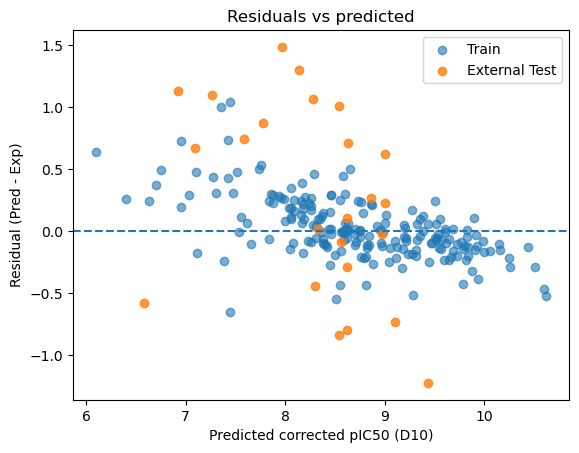

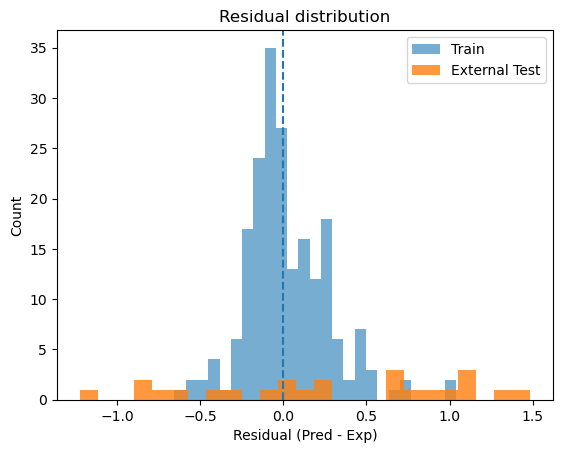

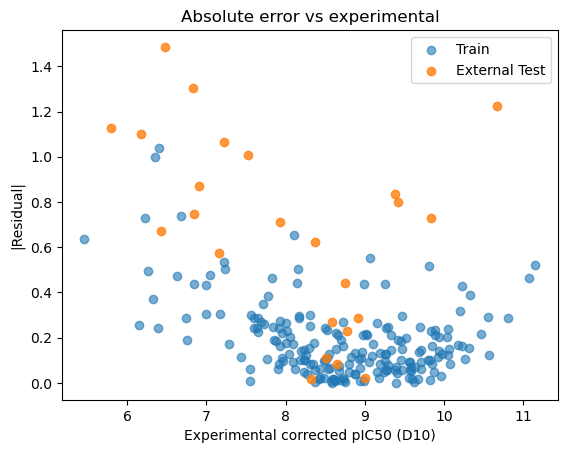

In [19]:
# 17) Residual plots
res_tr = pred_train - y_train
res_te = pred_test - y_test

plt.figure()
plt.scatter(pred_train, res_tr, alpha=0.6, label="Train")
plt.scatter(pred_test,  res_te, alpha=0.8, label="External Test")
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted corrected pIC50 (D10)")
plt.ylabel("Residual (Pred - Exp)")
plt.title("Residuals vs predicted")
plt.legend()
plt.show()

plt.figure()
plt.hist(res_tr, bins=25, alpha=0.6, label="Train")
plt.hist(res_te, bins=25, alpha=0.8, label="External Test")
plt.axvline(0, linestyle="--")
plt.xlabel("Residual (Pred - Exp)")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.legend()
plt.show()

plt.figure()
plt.scatter(y_train, np.abs(res_tr), alpha=0.6, label="Train")
plt.scatter(y_test,  np.abs(res_te), alpha=0.8, label="External Test")
plt.xlabel("Experimental corrected pIC50 (D10)")
plt.ylabel("|Residual|")
plt.title("Absolute error vs experimental")
plt.legend()
plt.show()

## 8. Learning curve (is the dataset limiting?)
Walters often uses simple plots that help interpret *why performance is what it is*.
Learning curves show whether more data would likely help.


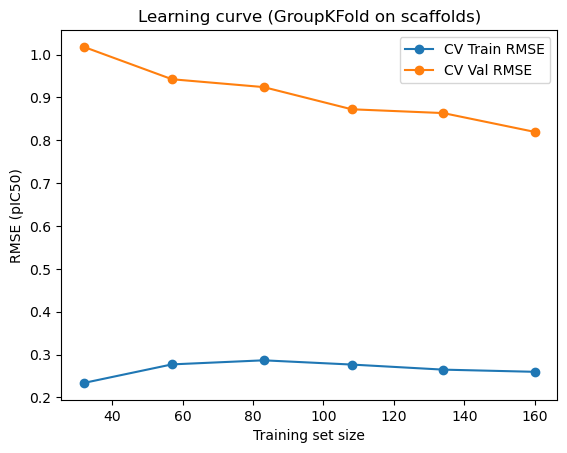

In [20]:
# 18) Learning curve (RMSE)
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train,
    cv=cv_iter,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1,
    random_state=RANDOM_SEED
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse  = np.sqrt(-test_scores.mean(axis=1))

plt.figure()
plt.plot(train_sizes, train_rmse, marker="o", label="CV Train RMSE")
plt.plot(train_sizes, test_rmse, marker="o", label="CV Val RMSE")
plt.xlabel("Training set size")
plt.ylabel("RMSE (pIC50)")
plt.title("Learning curve (GroupKFold on scaffolds)")
plt.legend()
plt.show()

## 9. Feature importance (Permutation importance on external)
Permutation importance is generally more reliable than RF impurity importance.


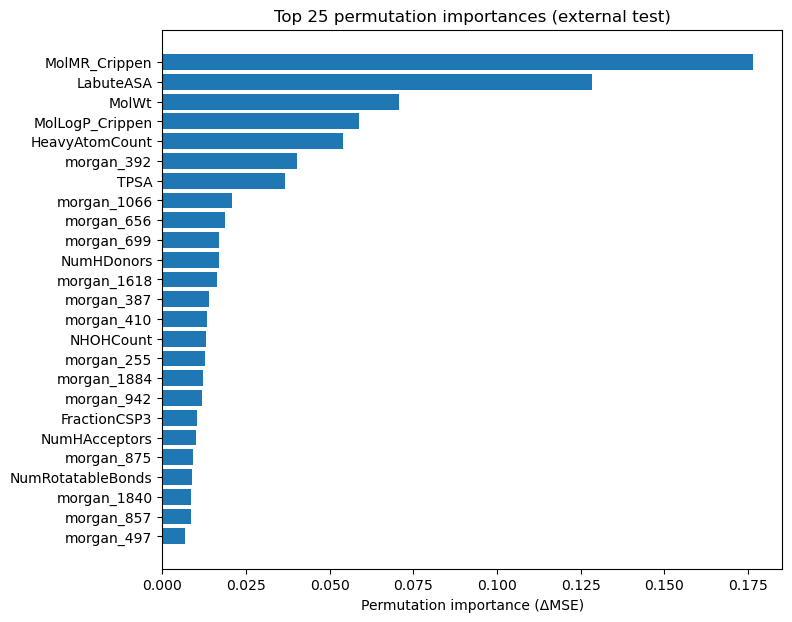

,feature,perm_mean,perm_std
10,MolMR_Crippen,0.176453,0.091119
13,LabuteASA,0.128311,0.054085
0,MolWt,0.070786,0.027448
9,MolLogP_Crippen,0.058692,0.040650
1,HeavyAtomCount,0.054030,0.025246
406,morgan_392,0.040342,0.011092
7,TPSA,0.036508,0.028794
1080,morgan_1066,0.020691,0.005553
670,morgan_656,0.018861,0.011287
713,morgan_699,0.016983,0.006146


In [21]:
# 19) Permutation importance (external test)
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring="neg_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False)

top = perm_df.head(25).iloc[::-1]

plt.figure(figsize=(8,7))
plt.barh(top["feature"], top["perm_mean"])
plt.xlabel("Permutation importance (ΔMSE)")
plt.title("Top 25 permutation importances (external test)")
plt.show()

perm_df.head(10)

## 10. SHAP (safe mode)
Full SHAP on 2000+ Morgan bits can be heavy.
We follow a pragmatic approach:
- take **top-K features** by permutation importance
- fit a small explain model
- compute SHAP on a sample


C:\Users\hllpacke\AppData\Local\Temp\ipykernel_11436\3726120662.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xt[:n_shap], plot_type="bar", show=True)


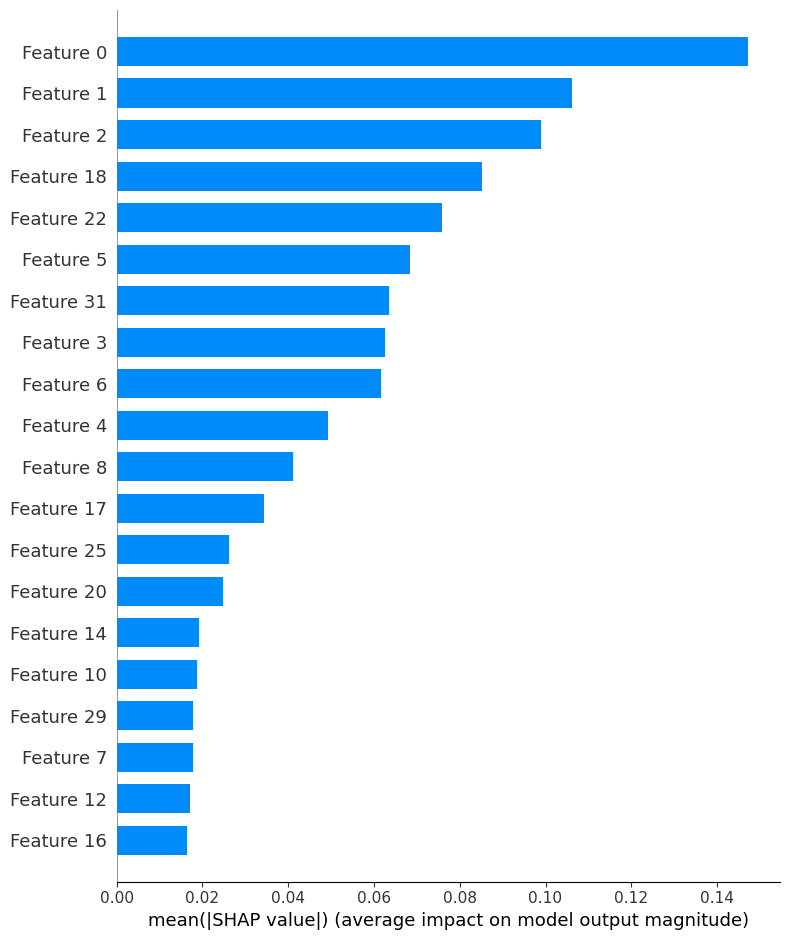

In [ ]:
# 20) SHAP (top-K) - optional
if not SHAP_AVAILABLE:
    print("Install SHAP to run this section: conda install -c conda-forge shap")
else:
    TOP_K = 60
    top_features = perm_df["feature"].head(TOP_K).tolist()

    Xtr_k = X_train[top_features].copy()
    Xte_k = X_test[top_features].copy()

    # reuse best RF hyperparams
    rf_params = {k.replace("rf__", ""): v for k, v in search.best_params_.items()}

    explain_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("var", VarianceThreshold(0.0)),
        ("rf", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **rf_params))
    ])
    explain_model.fit(Xtr_k, y_train)

    # transform to the RF feature space
    Xt = explain_model.named_steps["imputer"].transform(Xtr_k)
    Xt = explain_model.named_steps["var"].transform(Xt)

    rf_k = explain_model.named_steps["rf"]
    explainer = shap.TreeExplainer(rf_k)

    n_shap = min(250, Xt.shape[0])
    sv = explainer.shap_values(Xt[:n_shap])

    shap.summary_plot(sv, Xt[:n_shap], plot_type="bar", show=True)

## 11. Y-randomisation (chance correlation check)
We train the same model multiple times with shuffled y and see how often we beat the real model.
We report an **empirical p-value** and a **z-score**.


{'R2_real': 0.5863296308070605, 'R2_rand_mean': -0.3483734417635111, 'R2_rand_std': 0.16013412357568113, 'z': 5.837001206822628, 'empirical_p': 0.0}


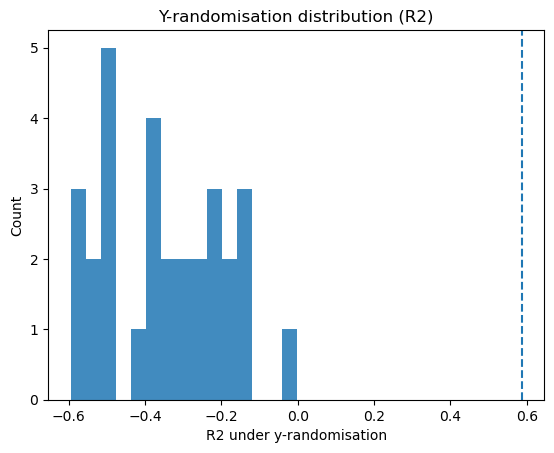

In [ ]:
# 21) Y-randomisation on external test R2
def y_randomisation_r2(n_perm=30, seed=42):
    rng = np.random.default_rng(seed)
    rf_params = {k.replace("rf__", ""): v for k, v in search.best_params_.items()}
    r2s = []
    for _ in range(n_perm):
        y_shuf = rng.permutation(y_train)
        m = Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("var", VarianceThreshold(0.0)),
            ("rf", RandomForestRegressor(random_state=seed, n_jobs=-1, **rf_params))
        ])
        m.fit(X_train, y_shuf)
        p = m.predict(X_test)
        r2s.append(r2_score(y_test, p))
    return np.array(r2s, float)

r2_rand = y_randomisation_r2(n_perm=30, seed=RANDOM_SEED)
r2_real = float(r2_score(y_test, pred_test))

mu, sd = float(np.mean(r2_rand)), float(np.std(r2_rand, ddof=1))
z = (r2_real - mu) / (sd + 1e-12)
p_emp = float(np.mean(r2_rand >= r2_real))

print({"R2_real": r2_real, "R2_rand_mean": mu, "R2_rand_std": sd, "z": float(z), "empirical_p": p_emp})

plt.figure()
plt.hist(r2_rand, bins=15, alpha=0.85)
plt.axvline(r2_real, linestyle="--")
plt.xlabel("R2 under y-randomisation")
plt.ylabel("Count")
plt.title("Y-randomisation distribution (R2)")
plt.show()

## 12. Applicability domain (SIM_5 to training)
Compute mean similarity to the 5 nearest training neighbours.
Low SIM_5 suggests extrapolation.


[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerator
[13:40:14] DEPRECATION WARNING: please use MorganGenerat

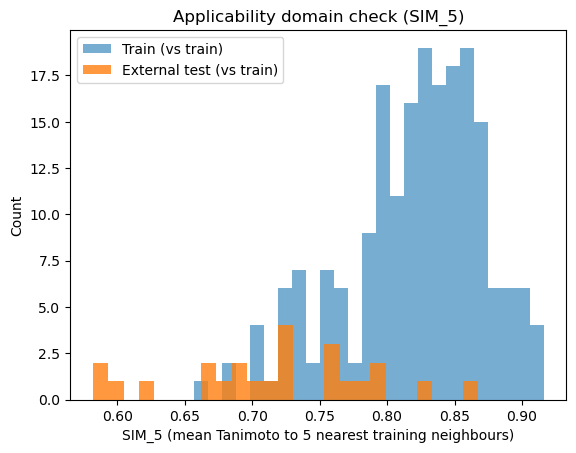

SIM_5 train mean: 0.8206282849180617 test mean: 0.7168391828960652


In [ ]:
# 22) Applicability domain: SIM_5 (Morgan) to training set
def morgan_fp_from_smiles(smi, radius=2, nbits=2048):
    m = Chem.MolFromSmiles(str(smi))
    if m is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits)

def sim5_to_training(smiles_query, smiles_train, radius=2, nbits=2048, k=5):
    fps_train = [morgan_fp_from_smiles(s, radius, nbits) for s in smiles_train]
    fps_train = [fp for fp in fps_train if fp is not None]
    out = []
    for s in smiles_query:
        fpq = morgan_fp_from_smiles(s, radius, nbits)
        if fpq is None or len(fps_train) == 0:
            out.append(np.nan)
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fpq, fps_train)
        sims_sorted = np.sort(np.array(sims))[::-1]
        out.append(float(np.mean(sims_sorted[:k])) if len(sims_sorted) >= k else float(np.mean(sims_sorted)))
    return np.array(out, float)

train_smiles = df.iloc[train_idx][smiles_col].astype(str).values
test_smiles  = df.iloc[test_idx][smiles_col].astype(str).values

sim5_train = sim5_to_training(train_smiles, train_smiles, radius=MORGAN_RADIUS, nbits=MORGAN_BITS, k=5)
sim5_test  = sim5_to_training(test_smiles,  train_smiles, radius=MORGAN_RADIUS, nbits=MORGAN_BITS, k=5)

plt.figure()
plt.hist(sim5_train[~np.isnan(sim5_train)], bins=25, alpha=0.6, label="Train (vs train)")
plt.hist(sim5_test[~np.isnan(sim5_test)],   bins=25, alpha=0.8, label="External test (vs train)")
plt.xlabel("SIM_5 (mean Tanimoto to 5 nearest training neighbours)")
plt.ylabel("Count")
plt.title("Applicability domain check (SIM_5)")
plt.legend()
plt.show()

print("SIM_5 train mean:", np.nanmean(sim5_train), "test mean:", np.nanmean(sim5_test))

## 13. External validation table (2D structures + correct experimental values)
We build a table for the external test set that includes:
- 2D structure
- SMILES (+ ID if available)
- Experimental corrected pIC50 (D10)
- Predicted corrected pIC50
- Error

We also include a strict alignment assertion.


In [ ]:
# 23) Alignment check (protect against mis-merge)
exp_from_df = df.iloc[test_idx][TARGET_COL].astype(float).values
assert np.allclose(exp_from_df, y_test), "Mismatch: y_test does not match df[TARGET_COL] for test_idx"
print("Alignment check: OK")

Alignment check: OK


In [ ]:
# 24) External validation table with 2D structures
ext = df.iloc[test_idx].copy()
ext["pIC50_exp"] = y_test
ext["pIC50_pred"] = pred_test
ext["error"] = ext["pIC50_pred"] - ext["pIC50_exp"]
ext["abs_error"] = np.abs(ext["error"])
ext["SIM_5"] = sim5_test

# render structures
PandasTools.RenderImagesInAllDataFrames(images=True)

cols = []
if id_col is not None:
    cols.append(id_col)
cols += ["Mol", smiles_col, "Scaffold", "SIM_5", "pIC50_exp", "pIC50_pred", "error", "abs_error"]

ext_tbl = ext[cols].sort_values("abs_error", ascending=False)
ext_tbl.head(50)

Failed to patch pandas - unable to change molecule rendering


,ID,Mol,Structure,Scaffold,SIM_5,pIC50_exp,pIC50_pred,error,abs_error
109,AMPT197,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,CS(=O)(=O)c1ccc(cc1)c2ccc(cc2)C(=O)N[C@@H](Cc3...,O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1ccc(-c2ccccc2)cc1,0.691912,6.481,7.966800,1.485800,1.485800
216,LQPI-30,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,CC1c2ccccc2CCN1C[C@H]([C@H](Cc3ccccc3)NC(=O)c4...,O=C(NC(CCN1CCc2ccccc2C1)Cc1ccccc1)c1ccc(C(=O)N...,0.581860,6.832,8.134794,1.302794,1.302794
114,AMPT202,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,CC(C)(C)C1CCN(CC1)C(=O)c2ccc(cc2)C(=O)N[C@@H](...,O=C(NC(CCNC1CCCC1)Cc1ccccc1)c1ccc(C(=O)N2CCCCC...,0.763019,10.660,9.435690,-1.224310,1.224310
97,AMPT174,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,c1ccc(cc1)C[C@@H]([C@@H](CNC2CCOCC2)O)NC(=O)c3...,O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1cccnc1,0.622177,5.800,6.928681,1.128681,1.128681
90,AMPT164,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccccc2)NC(=O)...,O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc2c(c1)CNC2=O,0.601168,6.170,7.268744,1.098744,1.098744
93,AMPT167,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccccc2)NC(=O)...,O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C2(N3CCNCC...,0.680023,7.218,8.282219,1.064219,1.064219
224,MT-1-16,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,C[C@@H](c1cscn1)NC[C@H]([C@H](Cc2cc(cc(c2)F)F)...,O=C(NC(CCNCc1cscn1)Cc1ccccc1)c1ccc(C(=O)N2CCNC...,0.726250,7.529,8.538271,1.009271,1.009271
94,AMPT168,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccccc2)NC(=O)...,O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1cccnc1,0.590263,6.907,7.776048,0.869048,0.869048
65,AMPT128,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,c1cc(ccc1C(=O)N[C@@H](Cc2cc(cc(c2)F)F)[C@@H](C...,O=C(NC(CCNC1CCCC1)Cc1ccccc1)c1ccc(C(=O)N2CCCCC...,0.822677,9.378,8.541196,-0.836804,0.836804
165,AMPT262,<rdkit.Chem.rdchem.Mol object at 0x0000013998B...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccccc2)NC(=O)...,O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CC3...,0.724800,9.421,8.621257,-0.799743,0.799743


## 14. Save the trained model
We save the pipeline (`best_model`) so you can reuse it later without retraining.


In [ ]:
# 25) Save model and metadata
import json
from datetime import datetime

MODEL_OUT = "pmx_rf_rdkit_morgan_model.joblib"
META_OUT = "pmx_rf_rdkit_morgan_model_meta.json"

joblib.dump(best_model, MODEL_OUT)

meta = {
    "created": datetime.now().isoformat(),
    "csv_path": CSV_PATH,
    "target_col": TARGET_COL,
    "smiles_col": smiles_col,
    "id_col": id_col,
    "morgan_radius": MORGAN_RADIUS,
    "morgan_bits": MORGAN_BITS,
    "desc_names": list(DESC_FUNCS.keys()),
    "best_params": search.best_params_
}
with open(META_OUT, "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:", MODEL_OUT, META_OUT)

Saved: pmx_rf_rdkit_morgan_model.joblib pmx_rf_rdkit_morgan_model_meta.json


## 15. Score new designed analogues (P2 bioisosteres)
### Workflow
1) Create a CSV of your new analogues with columns:
- `ID` (optional)
- `SMILES` (or `Structure`)
2) Set `NEW_CSV_PATH`
3) Run the cells below to get:
- predicted corrected pIC50
- 2D structures
- motif flags (quinoline / isoquinoline / quinazoline)
- top predicted (potent) vs bottom predicted (low)


In [14]:
# 26) Load model (optional) + define feature builder for new molecules
# If you've restarted kernel, you can load the saved model:
# Ensure sections 1-5 are ran first, check path of the .joblib file, and copy the realtive path, pasting it below:
best_model = joblib.load("M:\CHEM480\PMX ML\outputs\pmx_regressor_v1\data\pmx_rf_rdkit_morgan_model.joblib")

def featurize_smiles(smiles_list):
    mols = []
    desc_rows = []
    fp_rows = []
    valid = []
    for i, s in enumerate(smiles_list):
        m = Chem.MolFromSmiles(str(s))
        if m is None:
            continue
        mols.append(m)
        desc_rows.append(compute_desc(m))
        fp_rows.append(compute_morgan_bits(m, radius=MORGAN_RADIUS, n_bits=MORGAN_BITS))
        valid.append(i)
    Xd = pd.DataFrame(desc_rows)
    Xf = pd.DataFrame(fp_rows, columns=[f"morgan_{i}" for i in range(MORGAN_BITS)])
    Xnew = pd.concat([Xd, Xf], axis=1)
    return Xnew, mols, valid

def has_substruct(smiles, smarts):
    m = Chem.MolFromSmiles(str(smiles))
    if m is None: 
        return False
    q = Chem.MolFromSmarts(smarts)
    return bool(m.HasSubstructMatch(q)) if q is not None else False

In [15]:
# 27) Score new molecules from CSV
NEW_CSV_PATH = "PresentationAnalogues.csv"  

new_df = pd.read_csv(NEW_CSV_PATH)

new_smiles_col = next((c for c in CAND_SMILES if c in new_df.columns), None)
new_id_col = next((c for c in CAND_ID if c in new_df.columns), None)

if new_smiles_col is None:
    raise ValueError(f"New CSV needs a SMILES column. Looked for {CAND_SMILES}. Columns: {list(new_df.columns)}")

smiles_list = new_df[new_smiles_col].astype(str).tolist()
Xnew, mols, valid_idx = featurize_smiles(smiles_list)

# map back
scored = new_df.iloc[valid_idx].copy()
scored["Mol"] = mols
scored["pIC50_pred"] = best_model.predict(Xnew)

# motif flags (simple, adjust SMARTS if your P2 fragment is defined more specifically)
scored["has_quinoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1ccc2ncccc2c1"))  # quinoline
scored["has_isoquinoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1ccc2ccncc2c1")) # isoquinoline-like
scored["has_quinazoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1nc2ccccc2nc1")) # quinazoline

PandasTools.RenderImagesInAllDataFrames(images=True)

cols = []
if new_id_col is not None:
    cols.append(new_id_col)
cols += ["Mol", new_smiles_col, "pIC50_pred", "has_quinoline", "has_isoquinoline", "has_quinazoline"]

scored_tbl = scored[cols].sort_values("pIC50_pred", ascending=False).reset_index(drop=True)
scored_tbl

[13:40:29] DEPRECATION WARNING: please use MorganGenerator
[13:40:29] DEPRECATION WARNING: please use MorganGenerator
[13:40:29] DEPRECATION WARNING: please use MorganGenerator
[13:40:29] DEPRECATION WARNING: please use MorganGenerator
[13:40:29] DEPRECATION WARNING: please use MorganGenerator
Failed to patch pandas - unable to change molecule rendering


,ID,Mol,SMILES,pIC50_pred,has_quinoline,has_isoquinoline,has_quinazoline
0,Indole-methyl,<rdkit.Chem.rdchem.Mol object at 0x000001F1C80...,O=C(N[C@]([C@]([H])(O)CN[C@@](C1=CC=CC=C1)(C)[...,9.792565,False,False,False
1,Quinoline,<rdkit.Chem.rdchem.Mol object at 0x000001F1C80...,O=C(N[C@]([H])([C@](CN[C@@]([H])(C1=CC=CC=C1)C...,9.618316,True,False,False
2,Morpholine-methyl1,<rdkit.Chem.rdchem.Mol object at 0x000001F1C80...,O[C@@H]([C@H](Cc1cc(F)cc(F)c1)NC(C2N(C)CC(C(N3...,8.413581,False,False,False
3,Morpholine-methyl2,<rdkit.Chem.rdchem.Mol object at 0x000001F1C80...,O[C@@H]([C@H](Cc1cc(F)cc(F)c1)NC(C2OCC(C(N3CCN...,8.412806,False,False,False
4,Alkyne,<rdkit.Chem.rdchem.Mol object at 0x000001F1C80...,O[C@H](CN[C@@H](c1ccccc1)C)[C@@H](NC(C#CC(N2CC...,7.408180,False,False,False


In [19]:
# 27) Score new molecules from CSV
NEW_CSV_PATH = "Novel-Analogues.csv"  

new_df = pd.read_csv(NEW_CSV_PATH)

new_smiles_col = next((c for c in CAND_SMILES if c in new_df.columns), None)
new_id_col = next((c for c in CAND_ID if c in new_df.columns), None)

if new_smiles_col is None:
    raise ValueError(f"New CSV needs a SMILES column. Looked for {CAND_SMILES}. Columns: {list(new_df.columns)}")

smiles_list = new_df[new_smiles_col].astype(str).tolist()
Xnew, mols, valid_idx = featurize_smiles(smiles_list)

# map back
scored = new_df.iloc[valid_idx].copy()
scored["Mol"] = mols
scored["pIC50_pred"] = best_model.predict(Xnew)

# motif flags (simple, adjust SMARTS if your P2 fragment is defined more specifically)
scored["has_quinoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1ccc2ncccc2c1"))  # quinoline
scored["has_isoquinoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1ccc2ccncc2c1")) # isoquinoline-like
scored["has_quinazoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1nc2ccccc2nc1")) # quinazoline

PandasTools.RenderImagesInAllDataFrames(images=True)

cols = []
if new_id_col is not None:
    cols.append(new_id_col)
cols += ["Mol", new_smiles_col, "pIC50_pred", "has_quinoline", "has_isoquinoline", "has_quinazoline"]

scored_tbl = scored[cols].sort_values("pIC50_pred", ascending=False).reset_index(drop=True)
scored_tbl

[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerator
[16:02:42] DEPRECATION WARNING: please use MorganGenerat

,ID,Mol,Structure,pIC50_pred,has_quinoline,has_isoquinoline,has_quinazoline
0,AC-2-077,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,O=C(C1=CC=C(C(N2CCN(C)CC2)=O)C=C1)N[C@]([H])([...,9.813589,False,False,False
1,Indole1,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,O=C(C1=CNC2=C1C=CC(C(N3CCN(C)CC3)=O)=C2)N[C@](...,9.685409,False,False,False
2,Indole-2,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,O=C(C1=CC=C(C(N2CCN(C)CC2)=O)C3=C1NC=C3)N[C@](...,9.664173,False,False,False
3,Quinoline-9,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,9.663509,True,False,False
4,Quinoline-2,<rdkit.Chem.rdchem.Mol object at 0x000001767A2...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,9.618316,True,False,False
5,Indole2,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,O=C(C1=CC(C(N2CCN(C)CC2)=O)=CC3=C1C=CN3)N[C@](...,9.609233,False,False,False
6,Isoquinoline-1,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,9.597168,False,True,False
7,Quinoline-1,<rdkit.Chem.rdchem.Mol object at 0x000001767A1...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,9.596759,True,False,False
8,Isoquinoline-3,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,9.595027,False,True,False
9,Quinoline-3,<rdkit.Chem.rdchem.Mol object at 0x00000176795...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,9.586582,True,False,False


In [29]:
# 28) Pick one 'potent' and one 'weak' candidate automatically (by prediction)
best_row = scored_tbl.iloc[0]
worst_row = scored_tbl.iloc[-1]

print("Top predicted candidate:")
display(best_row)

print("\nLowest predicted candidate:")
display(worst_row)

Top predicted candidate:


ID                                                           AC-2-077
Mol                 <rdkit.Chem.rdchem.Mol object at 0x000002310B5...
Structure           O=C(C1=CC=C(C(N2CCN(C)CC2)=O)C=C1)N[C@]([H])([...
pIC50_pred                                                   9.813589
has_quinoline                                                   False
has_isoquinoline                                                False
has_quinazoline                                                 False
Name: 0, dtype: object


Lowest predicted candidate:


ID                                                       Morpholine-2
Mol                 <rdkit.Chem.rdchem.Mol object at 0x000002310B5...
Structure           O[C@@H]([C@H](Cc1cc(F)cc(F)c1)NC(C2OCC(C(N3CCN...
pIC50_pred                                                   8.134872
has_quinoline                                                   False
has_isoquinoline                                                False
has_quinazoline                                                 False
Name: 29, dtype: object

In [46]:
# 27) Score new molecules from CSV
NEW_CSV_PATH = "M:\CHEM480\PMX ML\outputs\pmx_regressor_v1\TCAMSHEA.csv"  # you will create this

new_df = pd.read_csv(NEW_CSV_PATH)

new_smiles_col = next((c for c in CAND_SMILES if c in new_df.columns), None)
new_id_col = next((c for c in CAND_ID if c in new_df.columns), None)

if new_smiles_col is None:
    raise ValueError(f"New CSV needs a SMILES column. Looked for {CAND_SMILES}. Columns: {list(new_df.columns)}")

smiles_list = new_df[new_smiles_col].astype(str).tolist()
Xnew, mols, valid_idx = featurize_smiles(smiles_list)

# map back
scored = new_df.iloc[valid_idx].copy()
scored["Mol"] = mols
scored["pIC50_pred"] = best_model.predict(Xnew)

# motif flags (simple, adjust SMARTS if your P2 fragment is defined more specifically)
scored["has_quinoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1ccc2ncccc2c1"))  # quinoline
scored["has_isoquinoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1ccc2ccncc2c1")) # isoquinoline-like
scored["has_quinazoline"] = scored[new_smiles_col].apply(lambda s: has_substruct(s, "c1nc2ccccc2nc1")) # quinazoline

PandasTools.RenderImagesInAllDataFrames(images=True)

cols = []
if new_id_col is not None:
    cols.append(new_id_col)
cols += ["Mol", new_smiles_col, "pIC50_pred", "has_quinoline", "has_isoquinoline", "has_quinazoline"]

scored_tbl = scored[cols].sort_values("pIC50_pred", ascending=False).reset_index(drop=True)
scored_tbl

[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerator
[12:07:04] DEPRECATION WARNING: please use MorganGenerat

,ID,Mol,Structure,pIC50_pred,has_quinoline,has_isoquinoline,has_quinazoline
0,StarDrop ID 6135,<rdkit.Chem.rdchem.Mol object at 0x0000023113E...,CCCc1cc(c(c(c1)N2CCCC2=O)F)C(=O)N[C@@H](Cc3ccc...,9.694456,False,False,False
1,StarDrop ID 10021,<rdkit.Chem.rdchem.Mol object at 0x00000231125...,CCCc1cc(c(c(c1)N2CCCC2=O)F)C(=O)N[C@@H](Cc3ccc...,9.694456,False,False,False
2,StarDrop ID 13880,<rdkit.Chem.rdchem.Mol object at 0x00000231125...,CCn1ccc2c1cc(cc2N3CCCCS3(=O)=O)C(=O)N[C@@H](Cc...,9.626237,False,False,False
3,StarDrop ID 15861,<rdkit.Chem.rdchem.Mol object at 0x0000023113F...,CCc1c[nH]c2c1cc(cc2N3CCCC3=O)C(=O)N[C@@H](Cc4c...,9.625672,False,False,False
4,StarDrop ID 8332,<rdkit.Chem.rdchem.Mol object at 0x00000231125...,CCc1c[nH]c2c1cc(cc2N3CCCC3=O)C(=O)N[C@@H](Cc4c...,9.625672,False,False,False
...,...,...,...,...,...,...,...
390,StarDrop ID 26474,<rdkit.Chem.rdchem.Mol object at 0x0000023113E...,CCc1cn2c3c1cc(cc3N(S(=O)(=O)CC2)C)C(=O)N[C@@H]...,7.139122,False,False,False
391,StarDrop ID 25410,<rdkit.Chem.rdchem.Mol object at 0x0000023113E...,CCc1cn2c3c1cc(cc3N(S(=O)(=O)CC2)C)C(=O)N[C@@H]...,7.139122,False,False,False
392,StarDrop ID 22310,<rdkit.Chem.rdchem.Mol object at 0x0000023113E...,CC(C)C[C@@H](C(=O)N)NC[C@@H]([C@H](Cc1ccccc1)N...,6.723255,False,False,False
393,StarDrop ID 16860,<rdkit.Chem.rdchem.Mol object at 0x0000023113F...,CC(C)C[C@@H](C(=O)N)NC[C@@H]([C@H](Cc1ccccc1)N...,6.647698,False,False,False


In [31]:
# 28) Pick one 'potent' and one 'weak' candidate automatically (by prediction)
best_row = scored_tbl.iloc[0]
worst_row = scored_tbl.iloc[-1]

print("Top predicted candidate:")
display(best_row)

print("\nLowest predicted candidate:")
display(worst_row)

Top predicted candidate:


ID                                                   StarDrop ID 6135
Mol                 <rdkit.Chem.rdchem.Mol object at 0x00000231091...
Structure           CCCc1cc(c(c(c1)N2CCCC2=O)F)C(=O)N[C@@H](Cc3ccc...
pIC50_pred                                                   9.694456
has_quinoline                                                   False
has_isoquinoline                                                False
has_quinazoline                                                 False
Name: 0, dtype: object


Lowest predicted candidate:


ID                                                  StarDrop ID 24392
Mol                 <rdkit.Chem.rdchem.Mol object at 0x000002310D4...
Structure           C[C@@H](C(=O)N)NC[C@@H]([C@H](Cc1ccccc1)NC(=O)...
pIC50_pred                                                   6.592831
has_quinoline                                                   False
has_isoquinoline                                                False
has_quinazoline                                                 False
Name: 394, dtype: object